In [50]:
import numpy as np
import matplotlib.pyplot as plt

In [51]:
pattern1 = np.array([
    [1, 1, 1, 1, 1],
    [1,-1, -1, -1, 1],
    [1, -1, 1, -1, 1],
    [1, -1, -1, -1, 1],
    [1, 1, 1, 1, 1]
]).flatten()

pattern2 = np.array([
    [1, 1, 1, -1 ,1],
    [-1, -1, 1, -1, 1],
    [1, 1, 1, 1, 1],
    [1, -1, 1, -1, -1],
    [1, -1, 1, 1, 1]
]).flatten()

In [52]:
def plot_pattern(p, title=""):
    plt.imshow(p.reshape(5,5), cmap="binary")
    plt.title(title)
    plt.axis("off")
    plt.show()

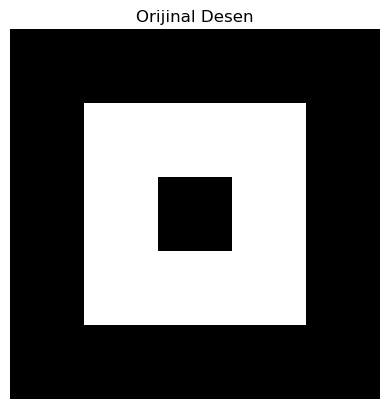

In [53]:
plot_pattern(pattern1, "Orijinal Desen")

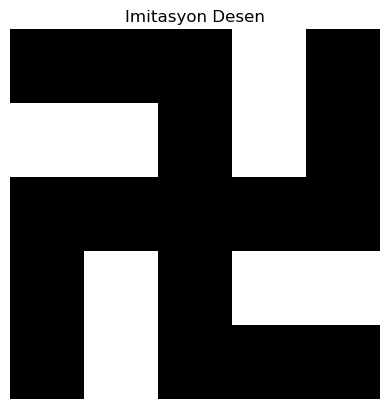

In [54]:
plot_pattern(pattern2, "Imitasyon Desen")

In [55]:
patterns = np.array([pattern1, pattern2])
n_neurons = pattern1.size

In [56]:
W = np.zeros((n_neurons, n_neurons))
for p in patterns:
    W += np.outer(p,p)
np.fill_diagonal(W,0)

In [58]:
test_pattern = pattern1.copy()
flip_indices = np.random.choice(range(n_neurons), size = int(0.4*n_neurons), replace=False)
test_pattern[flip_indices] *= -1

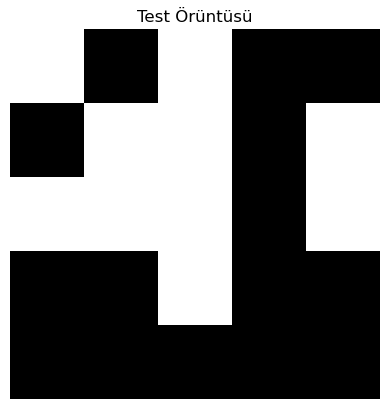

In [59]:
plot_pattern(test_pattern, "Test Örüntüsü")

In [61]:
def hopfield_update(state, W, steps= 10):
    for _ in range(steps):
        for i in range(len(state)):
            state[i] = 1 if np.dot(W[i], state) >= 0 else -1
    return state

In [62]:
recovered = hopfield_update(test_pattern.copy(), W)

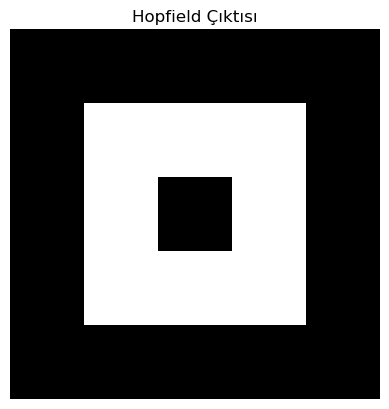

In [63]:
plot_pattern(recovered, "Hopfield Çıktısı")